In [9]:
from sklearn.neighbors import KNeighborsClassifier

#Q1

pg = 0.6
pb = 0.4

pdf_g = 0.5
pdf_b = 0.2
j_g = pg * pdf_g
j_b = pb * pdf_b
print(f"P(girl|x): {j_g / (j_g + j_b)}")
print(f"P(boy|x): {j_b / (j_g + j_b)}")

P(girl|x): 0.7894736842105263
P(boy|x): 0.21052631578947373


In [10]:
# Q2
x = 4
y_hat = 10 + 2 * x
y = 21

y - y_hat
# if greater than 0 => under prediction
# if loser than 0 => over prediction

3

In [11]:
# Q3
import numpy as np
from sklearn.neighbors import KNeighborsClassifier as knn

g_1 = np.random.normal(2, 1, 50)
class_1 = np.zeros(50)

g_2 = np.random.normal(8, 1, 50)
class_2 = np.ones(50)

x = np.hstack((g_1, g_2)).reshape(-1, 1)
y = np.hstack((class_1, class_2))

model = knn(metric='euclidean', n_neighbors=3)
model.fit(x, y)

y_hat = model.predict(x)

accuracy = model.score(x, y)
print(accuracy)

0.99


0.24197072451914337
0.05399096651318806


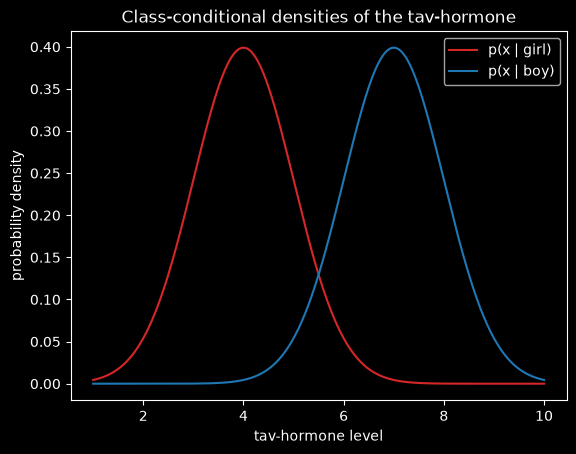

In [12]:
# Q4

#Q4
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

girl = stats.norm(loc=4, scale=1)
boy = stats.norm(loc=7, scale=1)
girl_pdf = girl.pdf(5)
boy_pdf = boy.pdf(5)
print(girl_pdf)
print(boy_pdf)
x = np.linspace(1, 10, 1000)
plt.plot(x, girl.pdf(x), color="tab:red", label="p(x | girl)")
plt.plot(x, boy.pdf(x), color="tab:blue", label="p(x | boy)")
plt.xlabel("tav-hormone level")
plt.ylabel("probability density")
plt.title("Class-conditional densities of the tav-hormone")
plt.legend()
plt.show()



In [ ]:
# Q5

from sklearn.linear_model import LinearRegression as LR

np.random.seed(42)
x = np.linspace(1, 10, 100)
noise = np.random.normal(loc=0, scale=2, size=100)
y = 3 * x + 5 + noise
plt.scatter(x, y)
model_reg = LR()
model_reg.fit(x.reshape(-1, 1), y)
print(f"coef:{model_reg.coef_}")
print(f"intercept:{model_reg.intercept_}")

In [ ]:
# Q6
import numpy as np
from sklearn.linear_model import LogisticRegression

g_1 = np.random.normal(2, 1, 50)
class_1 = np.zeros(50)

g_2 = np.random.normal(8, 1, 50)
class_2 = np.ones(50)

x = np.hstack((g_1, g_2)).reshape(-1, 1)
y = np.hstack((class_1, class_2))

log_reg = LogisticRegression()
log_reg.fit(x, y)
print(f"accuracy {log_reg.score(x, y)}")

In [ ]:
#Q7
import numpy as np


def sigmoid(z):
  return (1 / (np.exp(-z) + 1))


sigmoid(5)
sigmoid(0)
sigmoid(-5)

In [ ]:
# Q8
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

np.random.seed(42)

class0 = np.random.normal(loc=2, scale=2, size=50)
class1 = np.random.normal(loc=5, scale=4, size=50)

X = np.concatenate((class0, class1)).reshape(-1, 1)

# برچسب‌ها
y = np.array([0] * 50 + [1] * 50)

list_hyper = [1, 5, 20, 3, 100]

for n_neighbor in list_hyper:
  knn = KNeighborsClassifier(n_neighbors=n_neighbor)
  knn.fit(X, y)
  print(f"n-neighbor:{n_neighbor}\n {knn.score(X, y)}")
  print(f"n-neighbor:{n_neighbor}\n {knn.predict(X)}")

In [ ]:
#Q9
import numpy as np

arr = np.array([1, 10, 5, 3, 7, 18, 19, 11, 13, 4])
print(np.mean(arr))
print(np.std(arr))



In [ ]:
# Q10
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

g_10 = np.random.normal(2, 1, 50)
class_10 = np.zeros(50)

g_20 = np.random.normal(4, 5, 50)
class_20 = np.ones(50)

x = np.hstack((g_10, g_20)).reshape(-1, 1)
y = np.hstack((class_10, class_20))

log_reg = LogisticRegression()
log_reg.fit(x, y)
y_hat = log_reg.predict(x)

confusion_matrix(y, y_hat)

disp = ConfusionMatrixDisplay.from_predictions(
  y,
  y_hat,
  display_labels=log_reg.classes_,
  cmap=plt.cm.Blues
)
plt.title("Confusion Matrix (from_predictions)")
plt.show()


In [ ]:
# Q10
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

g_10 = np.random.normal(2, 2, 50)
class_10 = np.zeros(50)

g_20 = np.random.normal(8, 2, 50)
class_20 = np.ones(50)

x = np.hstack((g_10, g_20)).reshape(-1, 1)
y = np.hstack((class_10, class_20))

plt.scatter(x, np.ones_like(y), c=y)
plt.show()

Xtrain, Xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)
log_reg = LogisticRegression()
log_reg.fit(Xtrain, ytrain)
y_hat = log_reg.predict(Xtest)

confusion_matrix(ytest, y_hat)

disp = ConfusionMatrixDisplay.from_predictions(
  ytest,
  y_hat,
  display_labels=log_reg.classes_,
  cmap=plt.cm.Blues
)
plt.title("Confusion Matrix (from_predictions)")
plt.show()
print(f"accuracy {log_reg.score(Xtest, ytest)}")